<a href="https://colab.research.google.com/github/RaagulGananathan13/R26-IT-083/blob/raagul/Model1_Image_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# Setup

In [28]:
from google.colab import drive
drive.mount('/content/drive')
!pip install timm -q
import torch
print(f"GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f}GB")
print(f"Free VRAM: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1024**3:.1f}GB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: Tesla T4 | VRAM: 14.6GB
Free VRAM: 13.2GB


In [29]:
# Config

In [31]:
import os
IMG_DIR  = '/content/drive/MyDrive/Component_1/cardio_image_384'
CKPT_DIR = '/content/drive/MyDrive/Component_1/ckpt_image_model'
os.makedirs(CKPT_DIR, exist_ok=True)

# T4 GPU (15GB VRAM): batch_size=32 is optimal for ConvNeXt-Base @ 384x384 with AMP
# Uses ~11-12GB VRAM leaving headroom. For L4/A100 you can go to 64.
CFG = dict(img_size=384, batch_size=32, epochs=30, lr=3e-4, min_lr=1e-6,
           weight_decay=1e-4, warmup_epochs=3, patience=7, seed=42, workers=4)
RESUME = None  # f'{CKPT_DIR}/last.pth' to resume

In [32]:
# Imports

In [33]:
import json, time, random, warnings
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = False  # False for speed
    torch.backends.cudnn.benchmark = True       # Auto-tune convolutions for fixed input size
seed_all(CFG['seed'])
device = torch.device('cuda')

In [35]:
# Data Loaders

In [36]:
m, s, sz = [0.485,0.456,0.406], [0.229,0.224,0.225], CFG['img_size']
train_tf = transforms.Compose([
    transforms.Grayscale(3), transforms.Resize((sz,sz)),
    transforms.RandomHorizontalFlip(0.5), transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.05,0.05), scale=(0.95,1.05)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(), transforms.Normalize(m, s),
    transforms.RandomErasing(p=0.2, scale=(0.02,0.08)),
])
eval_tf = transforms.Compose([
    transforms.Grayscale(3), transforms.Resize((sz,sz)),
    transforms.ToTensor(), transforms.Normalize(m, s),
])

train_ds = datasets.ImageFolder(f'{IMG_DIR}/train', train_tf)
val_ds   = datasets.ImageFolder(f'{IMG_DIR}/val',   eval_tf)
test_ds  = datasets.ImageFolder(f'{IMG_DIR}/test',  eval_tf)

train_loader = DataLoader(train_ds, CFG['batch_size'], shuffle=True, num_workers=CFG['workers'],
                          pin_memory=True, drop_last=True, persistent_workers=True, prefetch_factor=3)
val_loader   = DataLoader(val_ds, CFG['batch_size']*2, shuffle=False, num_workers=CFG['workers'],
                          pin_memory=True, persistent_workers=True, prefetch_factor=3)
test_loader  = DataLoader(test_ds, CFG['batch_size']*2, shuffle=False, num_workers=CFG['workers'],
                          pin_memory=True, persistent_workers=True, prefetch_factor=3)

print(f"Classes: {train_ds.class_to_idx}")  # negative=0, positive=1
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Classes: {'negative': 0, 'positive': 1}
Train: 36938 | Val: 4550 | Test: 4786


In [37]:
# ConvNeXt-Base Model (GradCAM Compatible)

In [38]:
class CardioClassifier(nn.Module):
    def __init__(self, drop=0.3):
        super().__init__()
        self.backbone = timm.create_model('convnext_base.fb_in22k_ft_in1k', pretrained=True, num_classes=0)
        # Freeze stem + stages 0-1
        for n, p in self.backbone.named_parameters():
            if any(k in n for k in ['stem', 'stages.0.', 'stages.1.']):
                p.requires_grad = False
        self.head = nn.Sequential(
            nn.LayerNorm(1024), nn.Dropout(drop), nn.Linear(1024, 2)
        )
        # GradCAM hook target: self.backbone.stages[3] (last conv stage)

    def forward(self, x):
        return self.head(self.backbone(x))

model = CardioClassifier().to(device)
t = sum(p.numel() for p in model.parameters())
tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Params: {t:,} total | {tr:,} trainable ({100*tr/t:.1f}%)")

Params: 87,570,562 total | 85,399,554 trainable (97.5%)


In [39]:
# Training Setup

In [40]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scaler = GradScaler()
spe = len(train_loader)

class LR:
    def __init__(self, opt, wu, tot, mn):
        self.opt=opt; self.wu=wu; self.tot=tot; self.mn=mn
        self.base=[g['lr'] for g in opt.param_groups]; self.n=0
    def step(self):
        self.n+=1
        s = self.n/max(1,self.wu) if self.n<=self.wu else 0.5*(1+np.cos(np.pi*(self.n-self.wu)/max(1,self.tot-self.wu)))
        for g,b in zip(self.opt.param_groups,self.base): g['lr']=max(self.mn, b*s)
    def lr(self): return self.opt.param_groups[0]['lr']

sched = LR(optimizer, CFG['warmup_epochs']*spe, CFG['epochs']*spe, CFG['min_lr'])

start_ep, best_auc, hist, noimp = 1, 0.0, [], 0
if RESUME and os.path.isfile(RESUME):
    ck = torch.load(RESUME, map_location=device, weights_only=False)
    model.load_state_dict(ck['model']); optimizer.load_state_dict(ck['opt'])
    scaler.load_state_dict(ck['scaler']); start_ep=ck['ep']+1
    best_auc=ck['best_auc']; hist=ck.get('hist',[]); sched.n=(start_ep-1)*spe
    print(f"Resumed ep {start_ep} | Best AUC: {best_auc:.4f}")

In [41]:
# Train & Eval

In [45]:
def train_ep(model, loader, epoch):
    model.train(); loss_sum, cor, tot = 0,0,0
    for imgs, labels in tqdm(loader, desc=f'Ep {epoch} Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            out = model(imgs); loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update(); sched.step()
        loss_sum += loss.item()*imgs.size(0); cor += (out.argmax(1)==labels).sum().item(); tot += len(labels)
    return loss_sum/tot, cor/tot

@torch.no_grad()
def evaluate(model, loader, desc='Val'):
    model.eval(); loss_sum, tot = 0, 0; preds_all, labels_all, probs_all = [],[],[]
    for imgs, labels in tqdm(loader, desc=desc, leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast():
            out = model(imgs); loss = criterion(out, labels)
        loss_sum += loss.item()*imgs.size(0); tot += len(labels)
        probs = torch.softmax(out,1)
        preds_all.extend(out.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())
        probs_all.extend(probs[:,1].cpu().numpy())
    y, yp, ypr = np.array(labels_all), np.array(preds_all), np.array(probs_all)
    return {'loss':loss_sum/tot, 'acc':(y==yp).mean(), 'auc':roc_auc_score(y,ypr)}, y, yp

In [43]:
# Training Loop

In [46]:
print('='*60+'\nTRAINING: Cardiomegaly Image Classifier\n'+'='*60)
t0 = time.time()
for ep in range(start_ep, CFG['epochs']+1):
    et = time.time()
    tl, ta = train_ep(model, train_loader, ep)
    vm, _, _ = evaluate(model, val_loader, 'Val')
    et = time.time()-et
    hist.append({'ep':ep,'tl':round(tl,5),'ta':round(ta,5),'vl':round(vm['loss'],5),'va':round(vm['acc'],5),'auc':round(vm['auc'],5),'t':round(et,1)})
    print(f"\nEp {ep}/{CFG['epochs']} ({et:.0f}s) | Train: loss={tl:.4f} acc={ta:.4f} | Val: loss={vm['loss']:.4f} acc={vm['acc']:.4f} AUC={vm['auc']:.4f}")
    ck = {'ep':ep,'model':model.state_dict(),'opt':optimizer.state_dict(),'scaler':scaler.state_dict(),'best_auc':best_auc,'hist':hist}
    if vm['auc'] > best_auc:
        best_auc = vm['auc']; ck['best_auc']=best_auc
        torch.save(ck, f'{CKPT_DIR}/best.pth'); print(f"  ★ BEST AUC: {best_auc:.4f}"); noimp=0
    else: noimp+=1; print(f"  No improve ({noimp}/{CFG['patience']})")
    torch.save(ck, f'{CKPT_DIR}/last.pth')
    with open(f'{CKPT_DIR}/history.json','w') as f: json.dump(hist,f,indent=2)
    if CFG['patience']>0 and noimp>=CFG['patience']: print("Early stopping."); break
print(f"\nDone in {(time.time()-t0)/60:.1f}min | Best AUC: {best_auc:.4f}")

TRAINING: Cardiomegaly Image Classifier


Ep 1 Train:   0%|          | 0/1154 [00:00<?, ?it/s]

Val:   0%|          | 0/72 [00:00<?, ?it/s]


Ep 1/30 (3620s) | Train: loss=0.5268 acc=0.7715 | Val: loss=0.4633 acc=0.8187 AUC=0.9165
  ★ BEST AUC: 0.9165


Ep 2 Train:   0%|          | 0/1154 [00:00<?, ?it/s]

...

Val:   0%|          | 0/72 [00:00<?, ?it/s]


Ep 8/30 (1003s) | Train: loss=0.4033 acc=0.8730 | Val: loss=0.4556 acc=0.8323 AUC=0.9124
  No improve (6/7)


Ep 9 Train:   0%|          | 0/1154 [00:00<?, ?it/s]

Val:   0%|          | 0/72 [00:00<?, ?it/s]


Ep 9/30 (1002s) | Train: loss=0.3873 acc=0.8827 | Val: loss=0.4534 acc=0.8398 AUC=0.9141
  No improve (7/7)
Early stopping.

Done in 197.0min | Best AUC: 0.9204


In [47]:
# Test Evaluation

In [48]:
model.load_state_dict(torch.load(f'{CKPT_DIR}/best.pth', map_location=device, weights_only=False)['model'])
tm, tl, tp = evaluate(model, test_loader, 'Test')
print('='*60+'\nTEST RESULTS\n'+'='*60)
print(f"Accuracy: {tm['acc']:.4f} | AUC: {tm['auc']:.4f}")
print(confusion_matrix(tl, tp))
print(classification_report(tl, tp, target_names=['Negative','Positive']))

Test:   0%|          | 0/75 [00:00<?, ?it/s]

TEST RESULTS
Accuracy: 0.8397 | AUC: 0.9179
[[1885  508]
 [ 259 2134]]
              precision    recall  f1-score   support

    Negative       0.88      0.79      0.83      2393
    Positive       0.81      0.89      0.85      2393

    accuracy                           0.84      4786
   macro avg       0.84      0.84      0.84      4786
weighted avg       0.84      0.84      0.84      4786



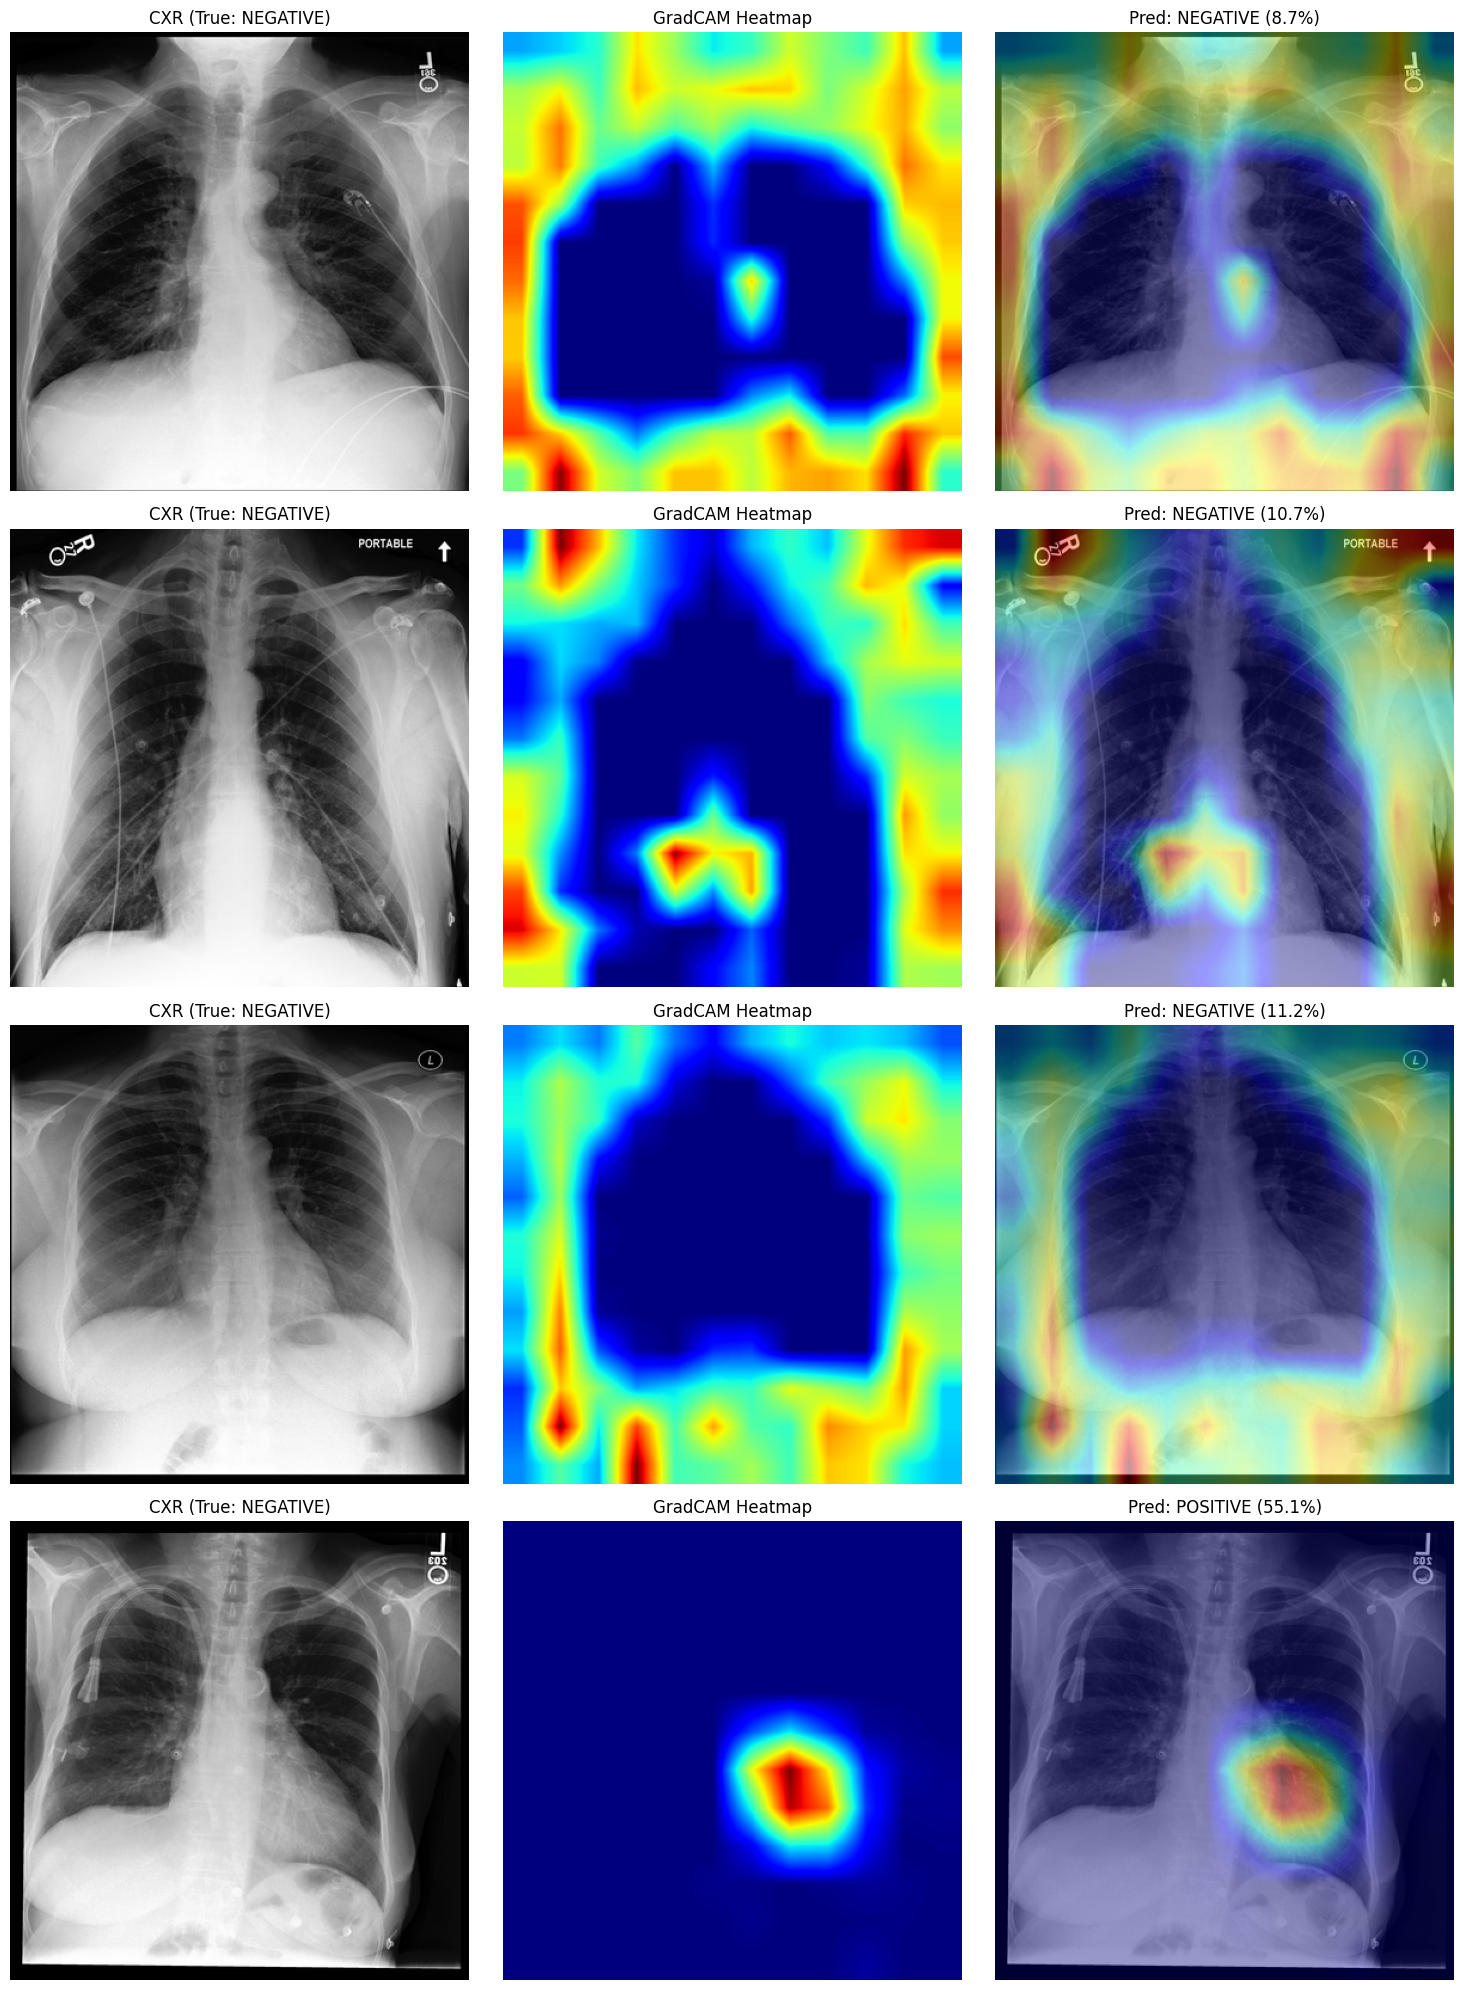

GradCAM saved!


In [60]:
# %% Cell 10: GradCAM Demo
import matplotlib.pyplot as plt
import torch.nn.functional as F

def denormalize(tensor, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
    """Reverse ImageNet normalization to get viewable image"""
    t = tensor.clone()
    for c in range(3):
        t[c] = t[c] * std[c] + mean[c]
    return t.clamp(0, 1)

def gradcam(model, img_tensor, target_class=1):
    model.eval()
    img = img_tensor.unsqueeze(0).to(device)

    features, grads = [], []
    def fwd_hook(module, inp, out):
        features.append(out.detach())
    def bwd_hook(module, grad_in, grad_out):
        grads.append(grad_out[0].detach())

    h1 = model.backbone.stages[3].register_forward_hook(fwd_hook)
    h2 = model.backbone.stages[3].register_full_backward_hook(bwd_hook)

    # Must use enable_grad — previous @torch.no_grad eval cell may linger
    with torch.enable_grad():
        out = model(img)
        model.zero_grad()
        out[0, target_class].backward()

    h1.remove(); h2.remove()

    if not grads or not features:
        print("WARNING: No gradients captured!")
        return np.zeros((CFG['img_size'], CFG['img_size'])), torch.softmax(out,1)[0].detach().cpu().numpy()

    w = grads[0].mean(dim=[2,3], keepdim=True)          # global avg pool gradients
    cam = F.relu((w * features[0]).sum(dim=1, keepdim=True))  # weighted combination
    cam = F.interpolate(cam, size=(CFG['img_size'],CFG['img_size']), mode='bilinear', align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)  # normalize to [0,1]
    return cam, torch.softmax(out,1)[0].detach().cpu().numpy()

# Show GradCAM on multiple test images
num_samples = 4
fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))

for i in range(num_samples):
    test_img, test_label = test_ds[i]
    cam, probs = gradcam(model, test_img, target_class=1)

    # Denormalize for proper display
    orig = denormalize(test_img)[0].numpy()  # channel 0 (all 3 are same for grayscale)

    pred = "POSITIVE" if probs[1] > 0.5 else "NEGATIVE"
    true = "POSITIVE" if test_label == 1 else "NEGATIVE"

    axes[i,0].imshow(orig, cmap='gray'); axes[i,0].set_title(f'CXR (True: {true})'); axes[i,0].axis('off')
    axes[i,1].imshow(cam, cmap='jet');   axes[i,1].set_title('GradCAM Heatmap');     axes[i,1].axis('off')
    axes[i,2].imshow(orig, cmap='gray'); axes[i,2].imshow(cam, cmap='jet', alpha=0.4)
    axes[i,2].set_title(f'Pred: {pred} ({probs[1]:.1%})'); axes[i,2].axis('off')

plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/gradcam_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("GradCAM saved!")
